In [586]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import nbinom

sns.set_theme(style="darkgrid", context="talk")

# Exercises part I: random problems

## Choosing the right support and avoiding aliasing

1) Change the value of N, first pick N > 13, then N < 13. What do you notice?

When N > 13, the plot increases in unused realestate along the y-axis. In fact, it is perfectly acceptable to choose a large N when the terms $e^{\frac{2\pi i m}{N}}$
are not too costly to evaluate.

However, when N < 13, the probability mass for the terms $p_n$ where $n \geq N$ will move to the beginning of the distribution, an effect known as aliasing. For instance, if we change the support to N = 12, the end of the distribution moves to the 0th position. 

2) n ∈ {0, 1, ..., N - 1} is the support of your probability distribution. When N-1 is below 12, we have aliasing. Fix N = 10, and now vary r between 0 and 1, What happens?

To select a reasonable `r`, we can write `r` <-> e^-1/k, where k should be around a few magnitudes smaller than N (usually). In fixing N = 10, with r = 1, as expected we see error in the distribution in that the last 3 positions shift to the front of the distribution. As we adjust r by making it smaller, we decrease the error. At r = .6, the error at the beginning of the distribution is no longer visible. However, we are still missing the tail. 

3) Instead of rolling two dice, now get the probability distribution for the sum of 3 dice. Repeat for more dice (5,10,20). What is the shape of the resulting probability distribution?

## Probability distribution for 3, 5, 10, and 20 dice

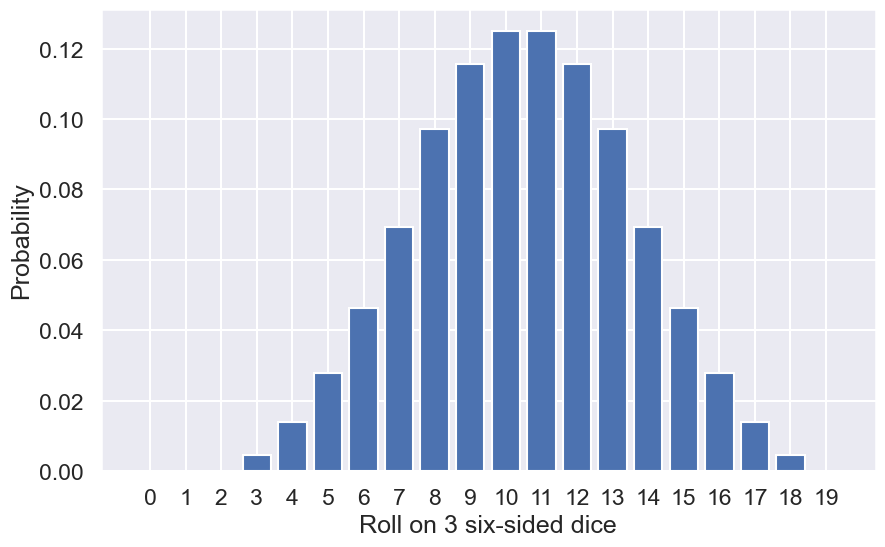

In [587]:
r = 1.
g = lambda x: np.sum([x**n/6 for n in range(1,7)])
G = lambda x: g(x)**3
G = np.vectorize(G)
N = 20
n = np.arange(N)
c = r*np.exp(2*np.pi*1j*n/N)
pn = abs(np.fft.fft(G(c))/(N*r**n))
plt.figure(figsize=(10, 6))
plt.bar(n,pn)
plt.xticks(n) 

plt.ylabel('Probability')
plt.xlabel('Roll on 3 six-sided dice')
plt.show()

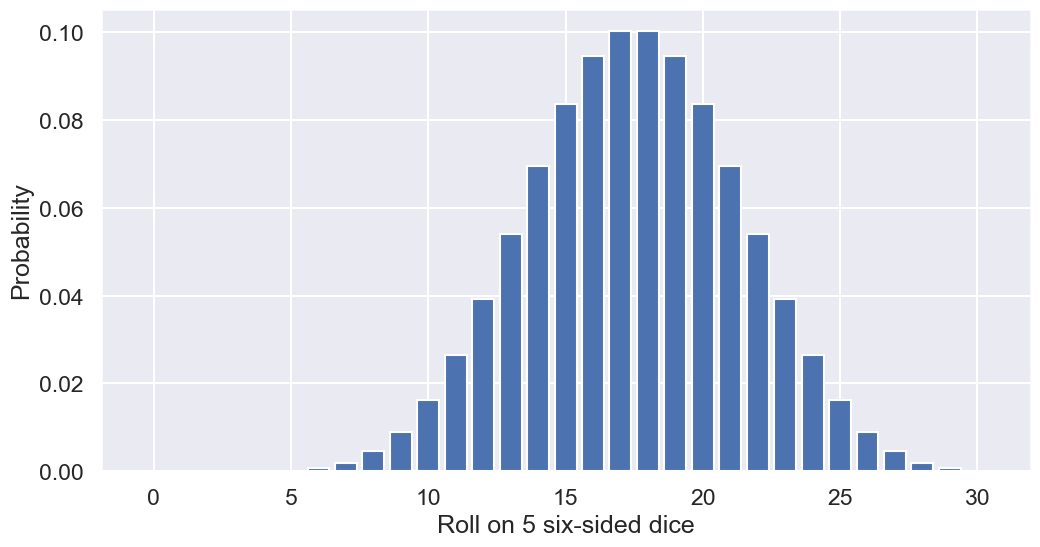

In [588]:
G = lambda x: g(x)**5
G = np.vectorize(G)
N = 31
n = np.arange(N)
c = r*np.exp(2*np.pi*1j*n/N)
pn = abs(np.fft.fft(G(c))/(N*r**n))
plt.figure(figsize=(12, 6))

plt.bar(n,pn)
plt.xticks(np.arange(0, 31, 5))

plt.ylabel('Probability')
plt.xlabel('Roll on 5 six-sided dice')
plt.show()

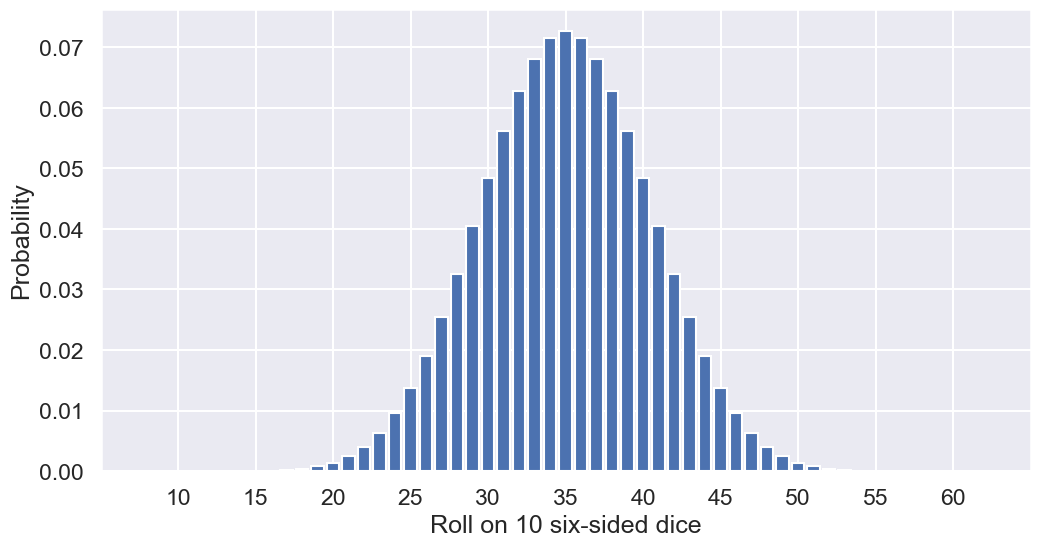

In [589]:
G = lambda x: g(x)**10
G = np.vectorize(G)
N = 61
n = np.arange(N)
c = r*np.exp(2*np.pi*1j*n/N)
pn = abs(np.fft.fft(G(c))/(N*r**n))
plt.figure(figsize=(12, 6))
plt.bar(n,pn)
plt.xlim(5, 65)  # Focus on the relevant range
plt.xticks(np.arange(10, 61, 5))
plt.ylabel('Probability')
plt.xlabel('Roll on 10 six-sided dice')
plt.show()

mean = np.sum(n * pn)
# print(f"Mean: {mean:.2f} (expected: 35)")

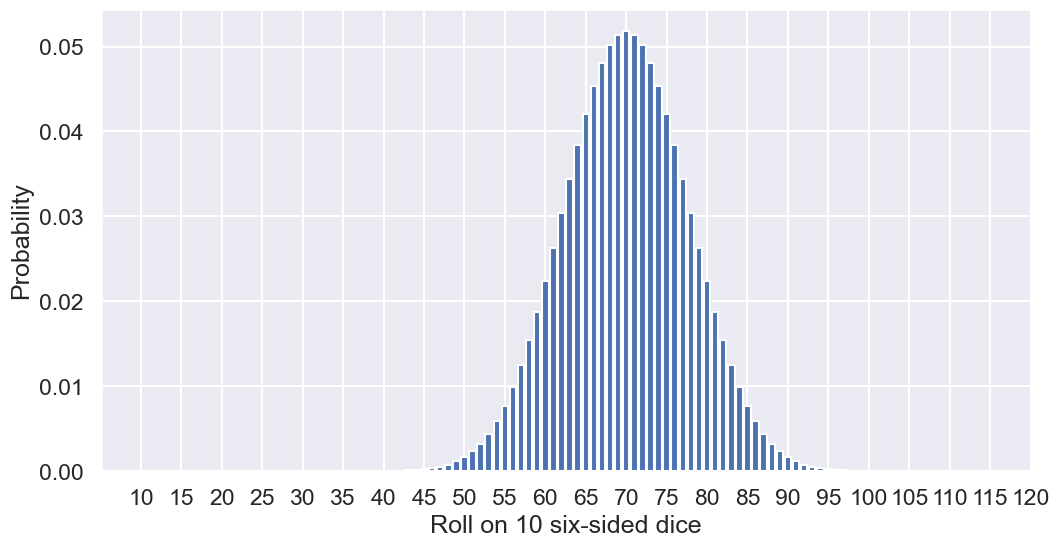

In [590]:
G = lambda x: g(x)**20
G = np.vectorize(G)
N = 121
n = np.arange(N)
c = r*np.exp(2*np.pi*1j*n/N)
pn = abs(np.fft.fft(G(c))/(N*r**n))
plt.figure(figsize=(12, 6))
plt.bar(n,pn)
plt.xlim(5, 65)  # Focus on the relevant range
plt.xticks(np.arange(10, 121, 5))
plt.ylabel('Probability')
plt.xlabel('Roll on 10 six-sided dice')
plt.show()

# mean = np.sum(n * pn)
# print(f"Mean: {mean:.2f} (expected: 35)")

# More complex scenarios

1) Get the probability distribution for the sum of a six-sided die and a twelve-sided die.

2) You have dice of a very weird shape. The PGF for the roll of a single die is 
g(x) = e^x-1. Extract the probability distribution and make sure you eliminate aliasing effects. Do the same using two dice.

## Probability distribution for the sum of a six-sided die and a twelve-sided die

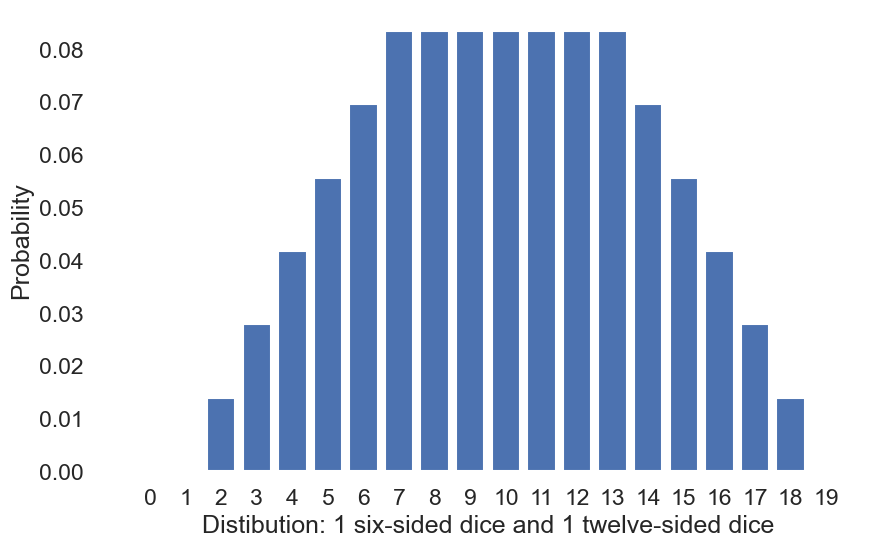

In [591]:
r = 1.
g_six = lambda x: np.sum([x**n/6 for n in range(1,7)])
g_twelve = lambda x: np.sum([x**n/12 for n in range(1,13)])
G = lambda x: g_six(x)*g_twelve(x)
G = np.vectorize(G)
N = 20
n = np.arange(N)
c = r*np.exp(2*np.pi*1j*n/N)
pn = abs(np.fft.fft(G(c))/(N*r**n))
plt.figure(figsize=(10, 6))

plt.bar(n,pn)
plt.ylabel('Probability')
plt.xlabel('Distibution: 1 six-sided dice and 1 twelve-sided dice')
plt.xticks(n)
plt.grid(False)
plt.gca().set_facecolor('white')  # white axes background
plt.show()

In [592]:
for outcome, prob in zip(n, pn):
    print(f"Sum = {outcome:2d}: Probability = {prob:.6f}")

Sum =  0: Probability = 0.000000
Sum =  1: Probability = 0.000000
Sum =  2: Probability = 0.013889
Sum =  3: Probability = 0.027778
Sum =  4: Probability = 0.041667
Sum =  5: Probability = 0.055556
Sum =  6: Probability = 0.069444
Sum =  7: Probability = 0.083333
Sum =  8: Probability = 0.083333
Sum =  9: Probability = 0.083333
Sum = 10: Probability = 0.083333
Sum = 11: Probability = 0.083333
Sum = 12: Probability = 0.083333
Sum = 13: Probability = 0.083333
Sum = 14: Probability = 0.069444
Sum = 15: Probability = 0.055556
Sum = 16: Probability = 0.041667
Sum = 17: Probability = 0.027778
Sum = 18: Probability = 0.013889
Sum = 19: Probability = 0.000000


## $g(x) = e^{x-1}$: Extract the probability distribution and make sure you eliminate aliasing effects. Do the same using two dice.

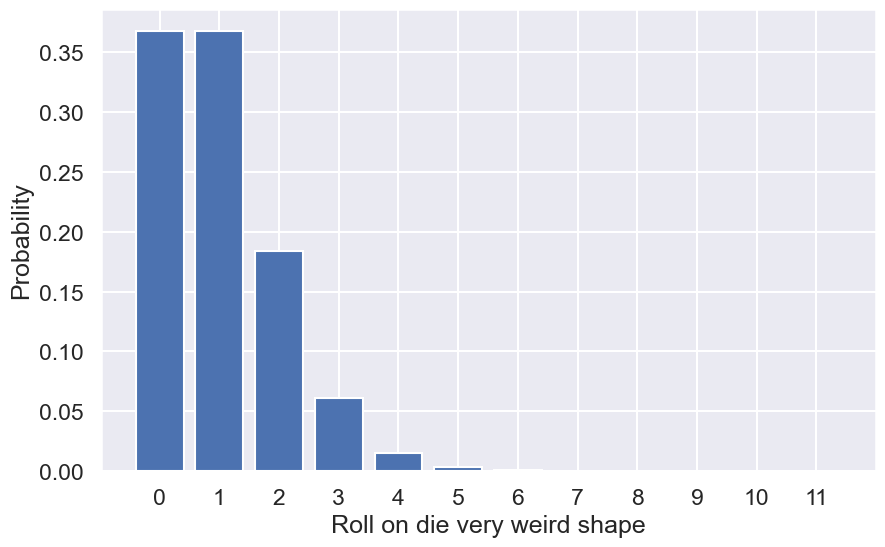

In [593]:
r = 1.
g = lambda x: np.exp(x-1)
G = lambda x: g(x)
G = np.vectorize(G)
N = 12
n = np.arange(N)
c = r*np.exp(2*np.pi*1j*n/N)
pn = abs(np.fft.fft(G(c))/(N*r**n))
plt.figure(figsize=(10, 6))
plt.bar(n,pn)
plt.xticks(n) 

plt.ylabel('Probability')
plt.xlabel('Roll on die very weird shape')
plt.show()

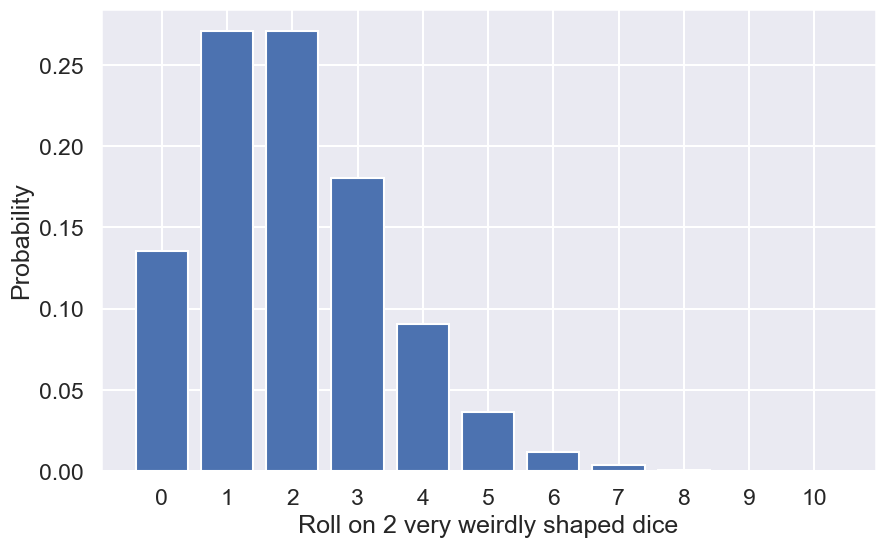

In [594]:
r = 1.
g = lambda x: np.exp(x-1)
G = lambda x: g(x)**2
G = np.vectorize(G)
N = 11
n = np.arange(N)
c = r*np.exp(2*np.pi*1j*n/N)
pn = abs(np.fft.fft(G(c))/(N*r**n))
plt.figure(figsize=(10, 6))
plt.bar(n,pn)
plt.xticks(n) 

plt.ylabel('Probability')
plt.xlabel('Roll on 2 very weirdly shaped dice')
plt.show()

## Not rocket science

1. First, construct the PGF $g(x,t)$ for the random variable $X_i(t)$ associated with a single engine.

$$g(x,t) = \left(\sum_{s=0}^{t} p_s\right) + \left(1 - \sum_{s=0}^{t} p_s\right) x$$

2. From $g(x,t)$, construct the PGF $G(x,t) = \sum_{n=1}^{12} p_{n,t} x^n$ for $X(t) = \sum_{i=1}^{12} X_i(t)$. What does the distribution $p_{n,t}$ represent?

The distribution $p_{n,t}$ represents:
- $p_{n,t}$ = probability that exactly $n$ engines (out of 12) are operational at time $t$
- This answers: "What's the probability of having exactly 0, 1, 2, ..., or 12 working engines at time $t$?"

3. Determine the probability of survival with each prototype. Which choice should you make? Could you have guessed this from the distributions above?

Given the distribution above, it would be hard to select the correct engine. Looking at the probabilities of survival for each engine, as seen below, engine B performs better with a cumulative probability of 82% while engine A is at 35%

4. If you are required to use 6 engines of type **A** and 6 engines of type **B**, calculate the probability of survival.

As seen below, if required to use 6 engines of each type, the probability of survival would be 61%

In [595]:
t_mission = np.arange(0, 21)
cumulative_failure_prob_A = np.sum(nbinom.pmf(t_mission, 32, 0.65))
cumulative_failure_prob_B = np.sum(nbinom.pmf(t_mission, 5, 0.2))
survival_prob_A = 1 - cumulative_failure_prob_A
survival_prob_B = 1 - cumulative_failure_prob_B
results = []
for n_A in range(13):
    n_B = 12 - n_A
    
    G_mix = lambda x: (g_1(x, survival_prob_A)**n_A) * (g_1(x, survival_prob_B)**n_B)
    G_mix = np.vectorize(G_mix)
    
    pn_mix = abs(np.fft.fft(G_mix(c))/N)
    
    prob_survival = np.sum(pn_mix[4:])
    results.append((n_A, n_B, prob_survival))
    print(f"{n_A}A, {n_B}B: {prob_survival:.4f}")

optimal = max(results, key=lambda x: x[2])
print(f"\nOptimal: {optimal[0]}A, {optimal[1]}B with {optimal[2]:.4f} survival probability")

0A, 12B: 0.8155
1A, 11B: 0.7890
2A, 10B: 0.7596
3A, 9B: 0.7274
4A, 8B: 0.6925
5A, 7B: 0.6549
6A, 6B: 0.6148
7A, 5B: 0.5727
8A, 4B: 0.5289
9A, 3B: 0.4841
10A, 2B: 0.4387
11A, 1B: 0.3936
12A, 0B: 0.3495

Optimal: 0A, 12B with 0.8155 survival probability


# Bacterial colony

1. Construct the PGF $g(x)$ describing the offspring distribution of a single bacterium. keep $p$ as a free parameter.

We could construct the PGF describing the offspring distribution of a single bacterium as such: 

$$g(x) = (1-p) + p x^2$$

2. Calculate the mean number of offsprings $\langle k \rangle$ numerically for different values of $p$. This corresponds to the *reproduction number* of the population.

    To find the mean, we leverage the PGF property, which states that we can arrive at the mean by taking the first derivative of $g(x)$ and evaluating at 1.

    $g'(x) = 2px$

    $g'(1) = 2p$

    Now if we evaluate at different values of $p$:

    $\langle k \rangle = 2 * .25 = 0.5$ high probability of extinction

    $\langle k \rangle = 2 * .50 = 1.0$ something close to a tipping point

    $\langle k \rangle = 2 * .75 = 1.5$ population could survive


3. Now assuming we start with 10 bacteria at generation 0, first construct the PGF $G(x)$ for the total offspring distribution of the population. Second, determine the distribution for the number of bacteria at generation 1 for $p = 0.25$, $p = 0.5$, and $p =  0.75$. What is the *probability of extinction* at generation 1?

Below I construct the PGF assuming we start with 10 bacteria at generation 0 and determine the distributions for the number of bacteria at generation 1 for the desired $p$ values. Then I plot the probability of extinction at generation 1, which indicates that extinction is almost certain up to $p=0.5$.



In [596]:
# construct PGF
Q = lambda p, x: (1 - p) + p * x**2
# start with 10 bacteria at gen 0
G0 = lambda x: x**10

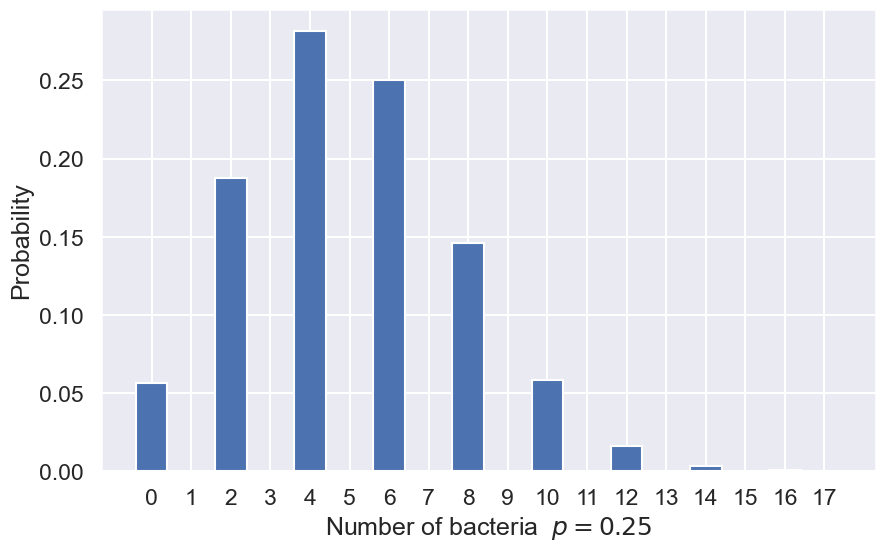

In [597]:

p = 0.25
N = 18
n = np.arange(N)
c = np.exp(2*np.pi*1j*n/N)
plt.figure(figsize=(10, 6))

# Get generation 1 distribution
pn = abs(np.fft.fft(G0(Q(p, c)))/N)

plt.xticks(n)
plt.bar(n,pn)
plt.ylabel('Probability')
plt.xlabel('Number of bacteria  $p=0.25$')
plt.show()

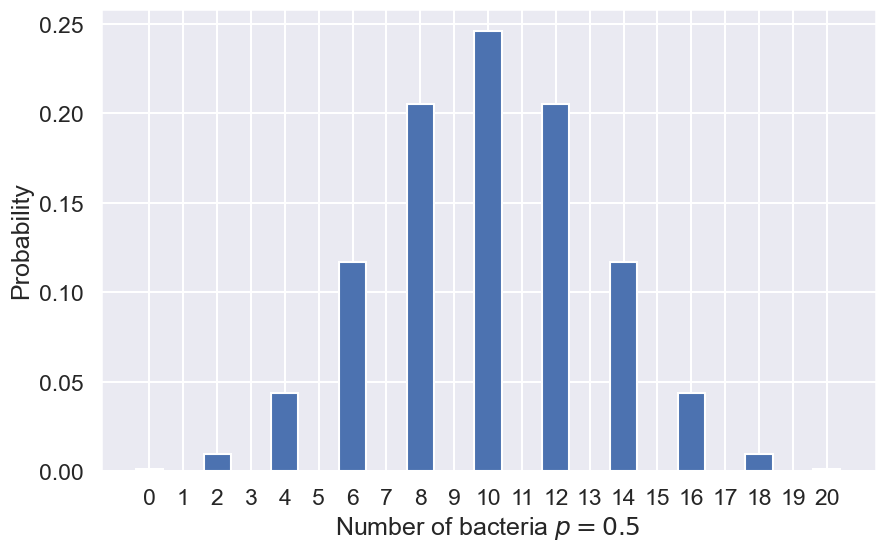

In [598]:

p = 0.50
N = 21
n = np.arange(N)
c = np.exp(2*np.pi*1j*n/N)
plt.figure(figsize=(10, 6))

# Get generation 1 distribution
pn = abs(np.fft.fft(G0(Q(p, c)))/N)

plt.xticks(n)
plt.bar(n,pn)
plt.ylabel('Probability')
plt.xlabel('Number of bacteria $p=0.5$')
plt.show()

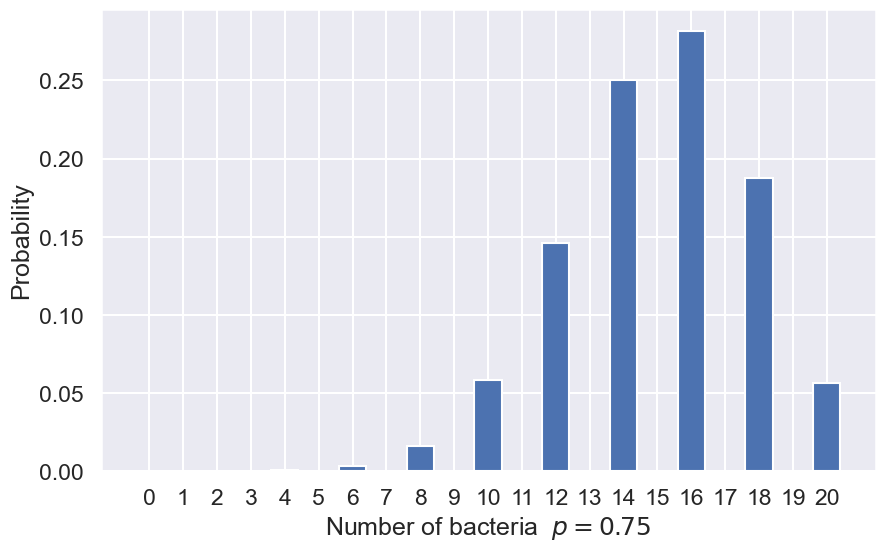

In [599]:

p = 0.75
N = 21
n = np.arange(N)
c = np.exp(2*np.pi*1j*n/N)
plt.figure(figsize=(10, 6))

# Get generation 1 distribution
pn = abs(np.fft.fft(G0(Q(p, c)))/N)

plt.xticks(n)
plt.bar(n,pn)
plt.ylabel('Probability')
plt.xlabel('Number of bacteria  $p=0.75$')
plt.show()

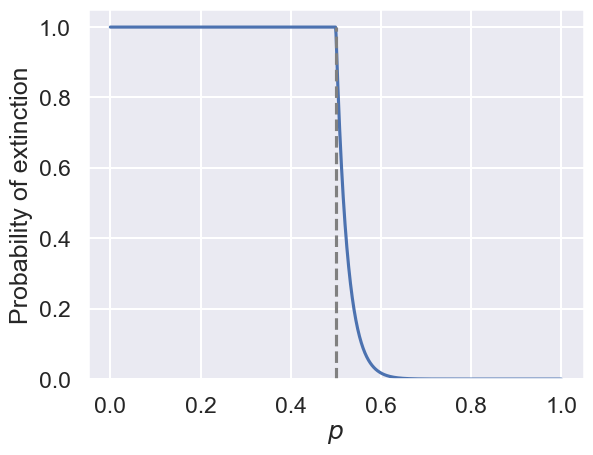

In [600]:
plist = np.linspace(0.0, 1.0, 1000)
usol = []
Pext = []

for p in reversed(plist):
    u1 = usol[-1].copy() if usol else 0.5
    u2 = Q(p, u1)
    while abs(u2 - u1) > 1e-10:
        u1 = u2.copy()
        u2 = Q(p, u1)

    usol.append(u2)
    Pext.append(G0(u2))

Pext = list(reversed(Pext))

plt.plot(plist, Pext)
plt.vlines(0.5, 0, 1, ls='--', color='grey')
plt.xlabel(r"$p$")
plt.ylabel("Probability of extinction")
plt.ylim(0, 1.05)
plt.show()


In [601]:
p_list_values = np.linspace(0, 1, 1000)
p_list = np.unique(np.concatenate([p_list_values, [0.25, 0.5, 0.75]]))
usol = []
Pext = []

for p in reversed(p_list):
    u1 = usol[-1].copy() if usol else 0.5
    u2 = Q(p, u1)
    while abs(u2 - u1) > 1e-10:
        u1 = u2.copy()
        u2 = Q(p, u1)

    usol.append(u2)
    Pext.append(G0(u2))
    if p in [0.25, 0.5, 0.75]:
        print(f"p={p:0.2f} Pext≈{G0(u2)*100:.2f}%")



p=0.75 Pext≈0.00%
p=0.50 Pext≈99.99%
p=0.25 Pext≈100.00%


4. What will happen in later generations? Can you construct the PGF associated with the number of bacteria at generation 2?

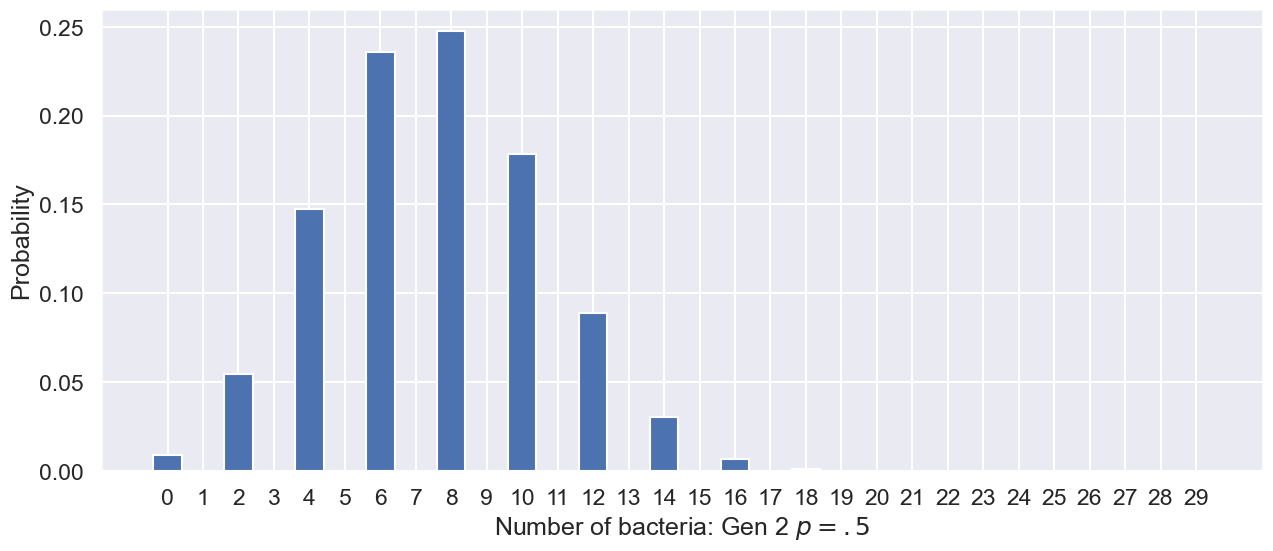

In [602]:

p = 0.5
N = 30
n = np.arange(N)
c = np.exp(2*np.pi*1j*n/N)
second_generation = G0(Q(Q(p, c), p))


# Get generation 1 distribution
pn = abs(np.fft.fft(second_generation)/N)
plt.figure(figsize=(15, 6))

plt.xticks(n)
plt.bar(n,pn)
plt.ylabel('Probability')
plt.xlabel('Number of bacteria: Gen 2 $p=.5$')
plt.show()

# Exercises part II: branching process

Change the offspring distribution to a negative binomial, using the PGF:

$Q(x) = \left [1 + \frac{R}{\kappa}(1-x) \right]^{-\kappa}$

Use different values of $\kappa > 0$ and see what happens. Take a very large value of $\kappa$ and compare with the Poisson case.

As we see below, as we increase $\kappa$, the negative binomial distribution becomes the Poisson. According to [wikipedia](https://en.wikipedia.org/wiki/Negative_binomial_distribution), this property of the negative binomial can be useful. For example, in epidemiology, one could imagine a case "where the likely number of onward infections may vary considerably from individual to individual and from setting to setting."

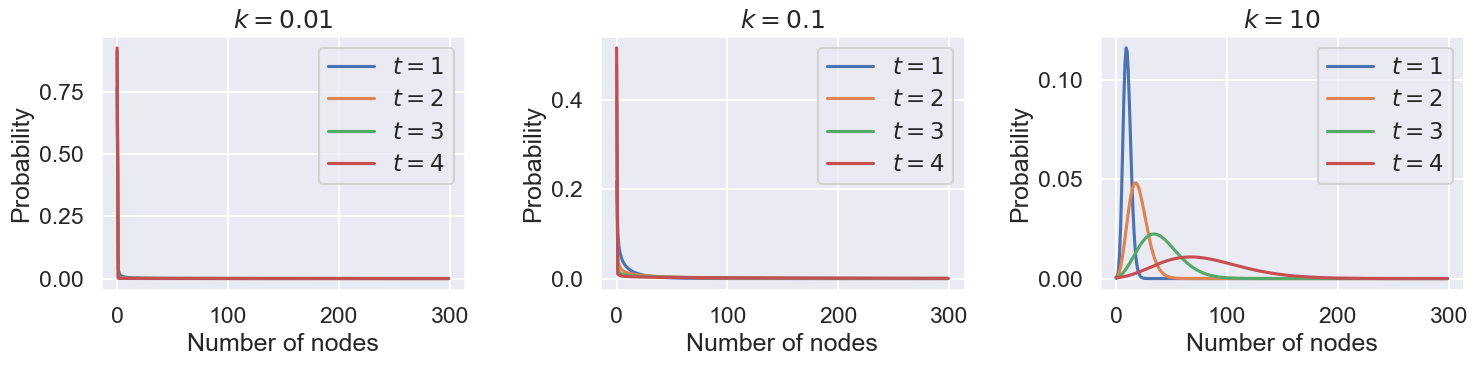

In [603]:
import numpy as np
import matplotlib.pyplot as plt

R = 2.
Q = lambda x, k: (1 + (R/k)*(1-x))**-k
G0 = lambda x: x**5

N = 300
n = np.arange(N)
c = np.exp(2*np.pi*1j*n/N)

tset = {1, 2, 3, 4}

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
k_values = [0.01, 0.1, 10]

for idx, k in enumerate(k_values):
    ax = axes[idx]
    x = c.copy()
    
    for t in range(max(tset)+1):
        if t in tset:
            pn = abs(np.fft.fft(G0(x))/N)
            ax.plot(n, pn, label=fr"$t = {t}$")
        x = Q(x, k)
    
    ax.legend()
    ax.set_ylabel('Probability')
    ax.set_xlabel('Number of nodes')
    ax.set_title(f'$k = {k}$')

plt.tight_layout()
plt.show()

1. Set $\kappa = 0.1$ and now extend the time to a large value (e.g., $t = 10$ should be enough). You should observe that $p_0$ (the *probability of extinction*) converge to a certain value.

As seen below, the probability of extinction does indeed converge at around $56.13%.

extinction probability = 56.13%


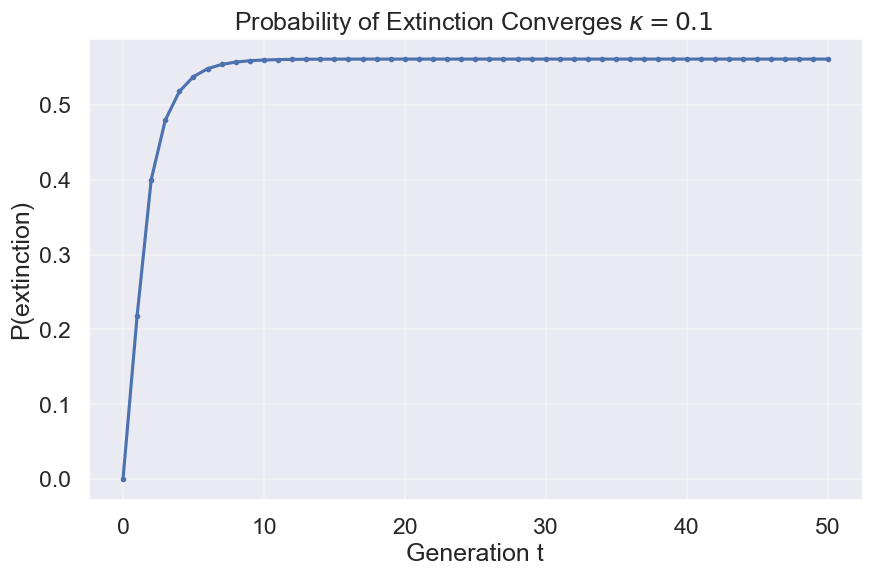

In [604]:
R = 2.
Q = lambda x, k: (1 + (R/k)*(1-x))**-k
G0 = lambda x: x**5

N = 300
n = np.arange(N)
c = np.exp(2*np.pi*1j*n/N)

max_t = 50
k_values = [0.01, 0.1, 10]

# Plot for each k value
plt.figure(figsize=(10, 6))

x = c.copy()
extinction_probs = []
time_points = []

for t in range(max_t + 1):
    pn = abs(np.fft.fft(G0(x))/N)
    extinction_probs.append(pn[0])
    # print(f"  t = {t}: P(extinction) = {pn[0]*100:.2f}%")
    time_points.append(t)
    x = Q(x, .1)

plt.plot(time_points, extinction_probs, marker='o', markersize=3)
print(f"extinction probability = {extinction_probs[-1]*100:.2f}%")

plt.xlabel('Generation t')
plt.ylabel('P(extinction)')
plt.title('Probability of Extinction Converges $\kappa = 0.1$ ')
plt.grid(True, alpha=0.3)
plt.show()

2. Change the initial condition $G_0(x)$ and see how this affects $p_0$ for large $t$.

As we see below, the probability of extinction decreases as $G_0(x)$ increases and seems to converge at t=100.


IC = 10: Final extinction probability = 31.56%
IC = 100: Final extinction probability = 0.33%
IC = 1000: Final extinction probability = 0.33%


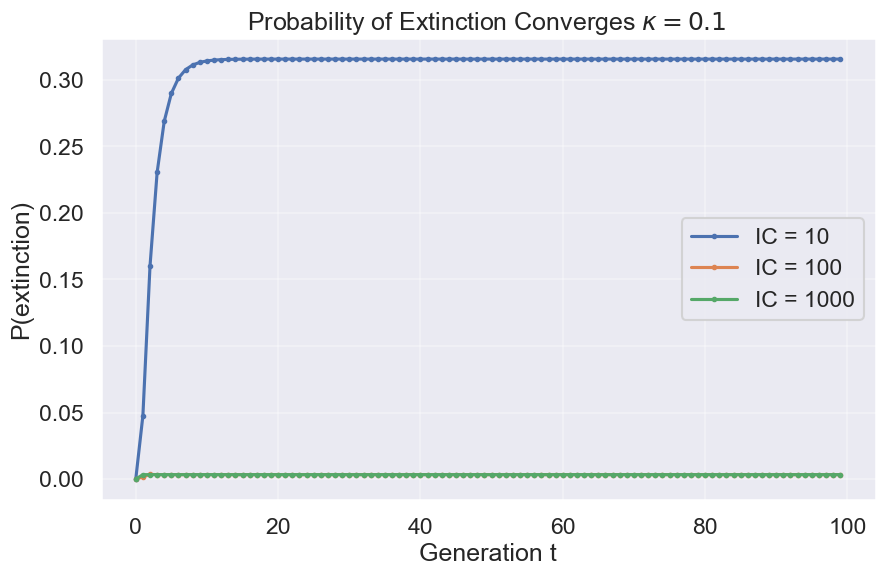

In [605]:
R = 2.
Q = lambda x, k: (1 + (R/k)*(1-x))**-k
G0 = lambda x, ic: x**ic

N = 300
n = np.arange(N)
c = np.exp(2*np.pi*1j*n/N)

max_t = 99
initial_conditions = [10, 100, 1000]

plt.figure(figsize=(10, 6))

for ic in initial_conditions:
    x = c.copy()
    extinction_probs = []
    time_points = []
    
    for t in range(max_t + 1):
        pn = abs(np.fft.fft(G0(x, ic))/N)
        extinction_probs.append(pn[0])
        time_points.append(t)
        x = Q(x, 0.1)
    
    plt.plot(time_points, extinction_probs, label=f'IC = {ic}', marker='o', markersize=3)
    print(f"IC = {ic}: Final extinction probability = {extinction_probs[-1]*100:.2f}%")

plt.xlabel('Generation t')
plt.ylabel('P(extinction)')
plt.title('Probability of Extinction Converges $\kappa = 0.1$ ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

3. Now vary $R$. Can you find a critical value $R_\mathrm{c}$ such that $p_0 = 1$ (for large $t$) for all $R < R_\mathrm{c}$? Does this value depend on $G_0(x)$ or $\kappa$"

Below, we first find the critical $R_c$, the we explore how $\kappa$ affects $R$, and lastly we explore how $G_0$ might affect dynamics. What we see is that $t$ is appropriately set, $R_c$ seems to behave the same way regardless of how these conditions are set. However, $G_0$ does seem to have more of an effect on the $p_0$ transition than $\kappa$.

In [606]:
Q = lambda x, k, R: (1 + (R/k)*(1-x))**-k
G0 = lambda x, ic: x**ic

N = 300
n = np.arange(N)
c = np.exp(2*np.pi*1j*n/N)

max_t = 1000 # for large t, convergence happens quickly here
r_values = np.linspace(0.1, 3.0, 200)
k = .1

# find R_c
print('Find critical R: R_c')
for R in r_values:
    x = c.copy()
    for t in range(max_t):
        x = Q(x, k, R)
    pn = abs(np.fft.fft(G0(x, 5))/N)
    if pn[0] > 0.9999:
        last_R_with_extinction = R
    else:
        print(f"  κ = {k:5.2f}: R_c ≈ {last_R_with_extinction:.4f} (p_0 transitions from 1.0000 to {pn[0]:.4f})")
        break

print('\n Does k affect R_c')
# does k affect R_c?
for k in [0.01, 0.1, 1, 10, 100, 1000]:
    last_R_with_extinction = None
    for R in r_values:
        x = c.copy()
        for t in range(max_t):
            x = Q(x, k, R)
        pn = abs(np.fft.fft(G0(x, 5))/N)
        
        if pn[0] > 0.99:  # Still essentially 1
            last_R_with_extinction = R
        else:
            # Found the transition!
            print(f"  κ = {k:5.2f}: R_c ≈ {last_R_with_extinction:.4f} (p_0 transitions from 1.0000 to {pn[0]:.4f})")
            break

print("\nDependence on G_0(x):")
for ic in [5, 10, 20, 40, 50, 100, 1000, 10000, 20000]:
    last_R_with_extinction = None
    for R in r_values:
        x = c.copy()
        for t in range(max_t):
            x = Q(x, 10, R)
        pn = abs(np.fft.fft(G0(x, ic))/N)
        
        if pn[0] > 0.99:
            last_R_with_extinction = R
        else:
            print(f"  IC = {ic:3d}: R_c ≈ {last_R_with_extinction:.4f} (p_0 transitions from 1.0000 to {pn[0]:.4f})")
            break


Find critical R: R_c
  κ =  0.10: R_c ≈ 0.9889 (p_0 transitions from 1.0000 to 0.9967)

 Does k affect R_c
  κ =  0.01: R_c ≈ 1.1055 (p_0 transitions from 1.0000 to 0.9891)
  κ =  0.10: R_c ≈ 1.0035 (p_0 transitions from 1.0000 to 0.9839)
  κ =  1.00: R_c ≈ 0.9889 (p_0 transitions from 1.0000 to 0.9821)
  κ = 10.00: R_c ≈ 0.9889 (p_0 transitions from 1.0000 to 0.9677)
  κ = 100.00: R_c ≈ 0.9889 (p_0 transitions from 1.0000 to 0.9649)
  κ = 1000.00: R_c ≈ 0.9889 (p_0 transitions from 1.0000 to 0.9646)

Dependence on G_0(x):
  IC =   5: R_c ≈ 0.9889 (p_0 transitions from 1.0000 to 0.9677)
  IC =  10: R_c ≈ 0.9889 (p_0 transitions from 1.0000 to 0.9365)
  IC =  20: R_c ≈ 0.9889 (p_0 transitions from 1.0000 to 0.8771)
  IC =  40: R_c ≈ 0.9889 (p_0 transitions from 1.0000 to 0.7693)
  IC =  50: R_c ≈ 0.9889 (p_0 transitions from 1.0000 to 0.7205)
  IC = 100: R_c ≈ 0.9889 (p_0 transitions from 1.0000 to 0.5194)
  IC = 1000: R_c ≈ 0.9889 (p_0 transitions from 1.0000 to 0.0047)
  IC = 10000: R

# Exercises part III: statistical inference

## Reusing the code for the PGF, estimate the posterior distribution on $R$.

Below, we use only the first and last data points, $n_0 = 1$ and $n_T$. You have that $G_0(x) = x^{n_0}$, and can calculate $G_T(x)$ (and the associated probability distribution).

In [607]:
# "Secret code"

def poisson_branching_process(T):
    R = 1.5
    n = [5]
    for t in range(1,T):
        n.append(np.random.poisson(R*n[t-1]))
    return n

def poisson_branching_process_with_noise(T):
    n = poisson_branching_process(T)
    n_out = [np.random.binomial(n_,0.1) for n_ in n]
    return n_out

[5, 11, 15, 23, 31, 56, 89, 134, 213, 292, 468, 723, 1090, 1654, 2415]
first_data_point = 5 last_data_point = 2415 len_pbp = 14


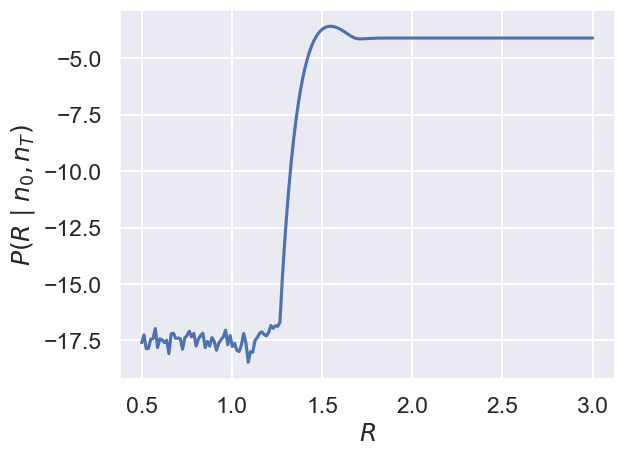

In [608]:
T = 15
t = np.arange(T)
n = poisson_branching_process(T)

first_data_point = int(n[0])
last_data_point = int(n[-1])
len_pbp = len(n) - 1
print(n)
print("first_data_point =", first_data_point, "last_data_point =", last_data_point, "len_pbp =", len_pbp)

r_values = np.linspace(0.5, 3.0, 200)
posterior = []

N = last_data_point + 10000
k = np.arange(N)
c = np.exp(2*np.pi*1j*k/N)
G0 = lambda x: x**first_data_point
Q  = lambda x: np.exp(R_candidate * (x - 1))
tset = {1,2,3,4}

for R_candidate in r_values:
    x = c.copy()
    for _ in range(len_pbp):
        x = Q(x)

        pn = abs(np.fft.fft(G0(x))/N)


    posterior.append(np.log10(pn[last_data_point]))

posterior = np.array(posterior)

# print(posterior)
# plt.semilogy(r_values, posterior)
plt.plot(r_values, posterior)
plt.xlabel(r"$R$")
plt.ylabel(r"$P(R\mid n_0, n_T)$")
plt.show()


## Try using more data points and breaking down the likelihood in a product (see below). Is the inference better?

$\prod_{j=1}^{T\tau} P\left(n_{j\tau}|n_{(j-1)\tau}, R\right)$



[0, 1, 1, 1, 3, 5, 7, 13, 9, 22, 38, 49, 74, 107, 139, 239, 381, 515, 747, 1108]
first_data_point = 0 last_data_point = 1108 len_pbp = 19


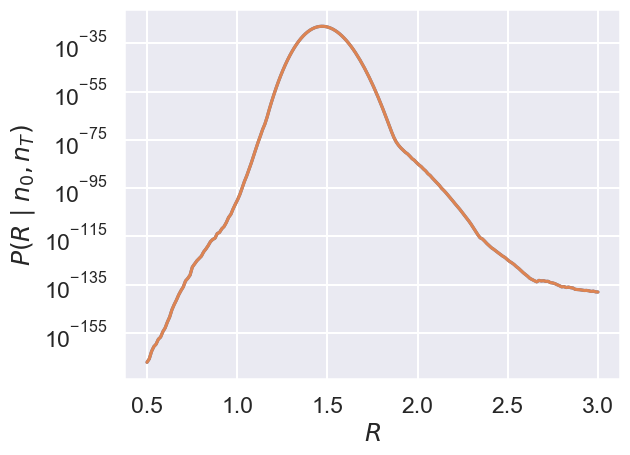

In [609]:
T = 20
t = np.arange(T)
n = poisson_branching_process_with_noise(T)

first_data_point = int(n[0])
last_data_point = int(n[-1])
len_pbp = len(n) - 1
print(n)
print("first_data_point =", first_data_point, "last_data_point =", last_data_point, "len_pbp =", len_pbp)

r_values = np.linspace(0.5, 3.0, 200)
posterior = []
posterior_combinations = []
N = last_data_point + 100
k = np.arange(N)
c = np.exp(2*np.pi*1j*k/N)
G0 = lambda x: x**first_data_point

for R_candidate in r_values:
    Q  = lambda x: np.exp(R_candidate * (x - 1))
    posterior = []

    for t in range(len_pbp):
        x = c.copy()
        first_data_point = n[t]
        G0 = lambda x: x**first_data_point
        last_data_point = n[t+1]
        if first_data_point > 0:
            x = Q(x)
            
            pn = abs(np.fft.fft(G0(x))/N)

            posterior.append(pn[last_data_point])
    posterior_combinations.append(np.prod(posterior))

posterior_combinations = np.array(posterior_combinations)
plt.semilogy(r_values,posterior_combinations)

plt.plot(r_values, posterior_combinations)
plt.xlabel(r"$R$")
plt.ylabel(r"$P(R\mid n_0, n_T)$")
plt.show()
